### 1. INTRODUCTION AND DATASET OVERVIEW

DATASET OVERVIEW:

DATASET NAME    : U.S. College Scorecard Dataset (2018–2020)

SOURCE          : https://collegescorecard.ed.gov/data

PROBLEM TYPE    : REGRESSION

TARGET VARIABLE : DEBT_MDN – Median Student Loan Debt at Completion

PURPOSE         : Predicting student debt burden based on institutional cost, admission rates and student demographics to analyze financial outcomes in higher education.

1.1 IMPORT LIBRARIES

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import zscore





### 2. DATA PRE-PROCESSING AND CLEANING

2.1 DATASET LOADING

In [23]:
# Load the dataset
df = pd.read_csv("MERGED_2.csv", low_memory=False)

2.2 DATA PRE-PROCESSING AND CLEANING

In [51]:

# Replacing 'PS' and empty strings with NaN
df.replace("PS", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)

# Retaining relevant columns
required_columns = [
    'UNITID', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 'CONTROL', 'REGION', 'ADM_RATE',
    'UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'MD_EARN_WNE_P10', 'MD_EARN_WNE_INC1_P10',
    'MD_EARN_WNE_INC2_P10', 'MD_EARN_WNE_INC3_P10', 'DEBT_MDN', 'GRAD_DEBT_MDN',
    'COSTT4_A', 'COSTT4_P', 'PCTPELL', 'RET_FT4', 'RET_FTL4', 'COMP_ORIG_YR4_RT',
    'LO_INC_RPY_1YR_RT', 'MD_INC_RPY_1YR_RT', 'HI_INC_RPY_1YR_RT'
]
selected_columns = [col for col in required_columns if col in df.columns]
df_selected = df[selected_columns]

# Dropping rows with all missing key values
key_columns = ['MD_EARN_WNE_P10', 'TUITIONFEE_IN', 'TUITIONFEE_OUT']
df_cleaned = df_selected.dropna(subset=key_columns, how='all')

# Dropping empty columns 
columns_to_drop = [
    'MD_EARN_WNE_P10', 'MD_EARN_WNE_INC1_P10', 'MD_EARN_WNE_INC2_P10', 'MD_EARN_WNE_INC3_P10',
    'LO_INC_RPY_1YR_RT', 'MD_INC_RPY_1YR_RT', 'HI_INC_RPY_1YR_RT', 'COSTT4_P'
]
df_cleaned = df_cleaned.drop(columns=[col for col in columns_to_drop if col in df_cleaned.columns])
df_cleaned = df_cleaned.dropna(axis=1, how='all')
df_cleaned.to_csv("MERGED2_CLEANED_FINAL.csv", index=False)

print("Rows after cleaning:", df_cleaned.shape[0])
print("Columns after cleaning:", df_cleaned.shape[1])


C:\Users\ACER\AppData\Local\Temp\ipykernel_16224\3572358657.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("PS", np.nan, inplace=True)


Rows after cleaning: 7702
Columns after cleaning: 18


2.3 DATASET OVERVIEW

In [31]:

# Plot theme 
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

file_path = "MERGED2_CLEANED_FINAL.csv"  # update with full path if needed
df = pd.read_csv(file_path)

# Dataset Overview
print("="*60)
print("Dataset Overview")
print("="*60)
print("Shape of the dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst five rows:\n", df.head())
print("="*60)


Dataset Overview
Shape of the dataset: (7702, 18)

Data types:
 UNITID                int64
INSTNM               object
CITY                 object
STABBR               object
ZIP                  object
CONTROL               int64
REGION                int64
ADM_RATE            float64
UGDS                float64
TUITIONFEE_IN       float64
TUITIONFEE_OUT      float64
DEBT_MDN            float64
GRAD_DEBT_MDN       float64
COSTT4_A            float64
PCTPELL             float64
RET_FT4             float64
RET_FTL4            float64
COMP_ORIG_YR4_RT    float64
dtype: object

First five rows:
    UNITID                               INSTNM        CITY STABBR         ZIP  \
0  100654             Alabama A & M University      Normal     AL       35762   
1  100663  University of Alabama at Birmingham  Birmingham     AL  35294-0110   
2  100690                   Amridge University  Montgomery     AL  36117-3553   
3  100706  University of Alabama in Huntsville  Huntsville     AL       358

### 3. EXPLORATORY DATA ANALYSIS (EDA)

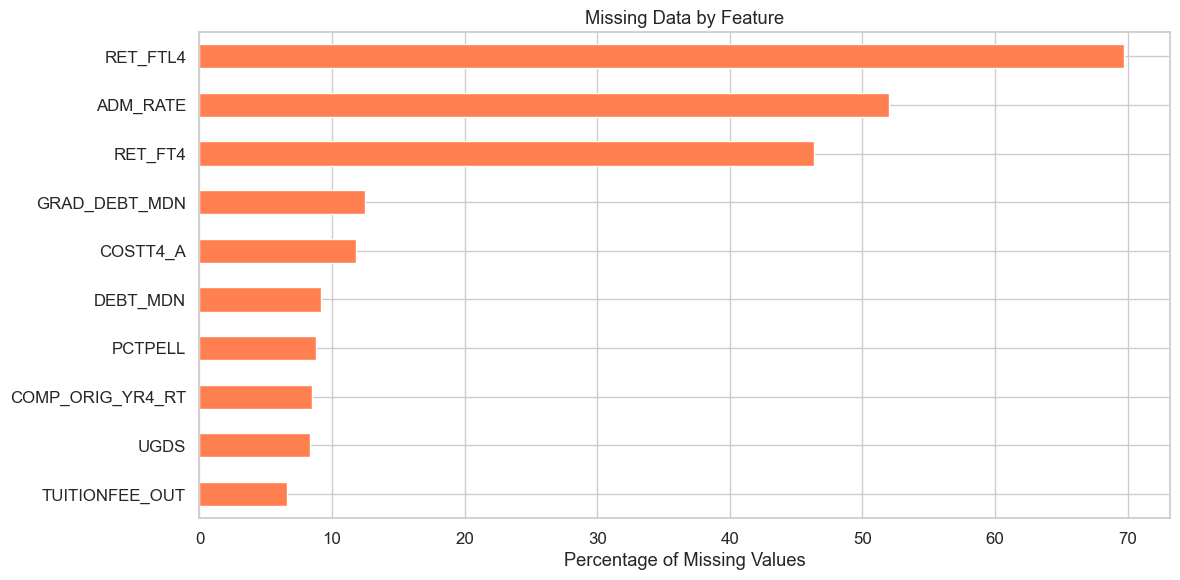

Missing Values Summary Table:

                  Missing Count  Missing %
RET_FTL4                   5371  69.735134
ADM_RATE                   4003  51.973513
RET_FT4                    3572  46.377564
GRAD_DEBT_MDN               962  12.490262
COSTT4_A                    910  11.815113
DEBT_MDN                    705   9.153467
PCTPELL                     678   8.802908
COMP_ORIG_YR4_RT            653   8.478317
UGDS                        641   8.322514
TUITIONFEE_OUT              506   6.569722
Descriptive Statistics of Numerical Features
                   count          mean           std            min  \
UNITID            7702.0  2.363715e+06  7.982828e+06  100654.000000   
CONTROL           7702.0  1.713451e+00  7.207560e-01       1.000000   
REGION            7702.0  4.485978e+00  2.157419e+00       0.000000   
ADM_RATE          3699.0  6.820348e-01  2.153839e-01       0.000000   
UGDS              7061.0  4.128248e+03  6.996409e+03       0.000000   
TUITIONFEE_IN     7702.0 

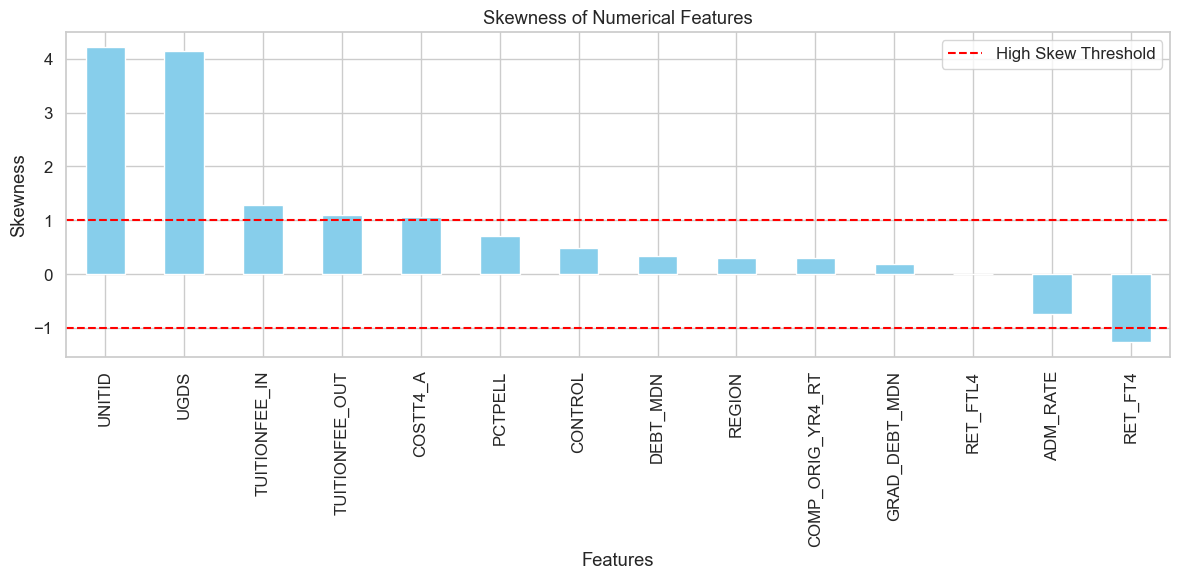

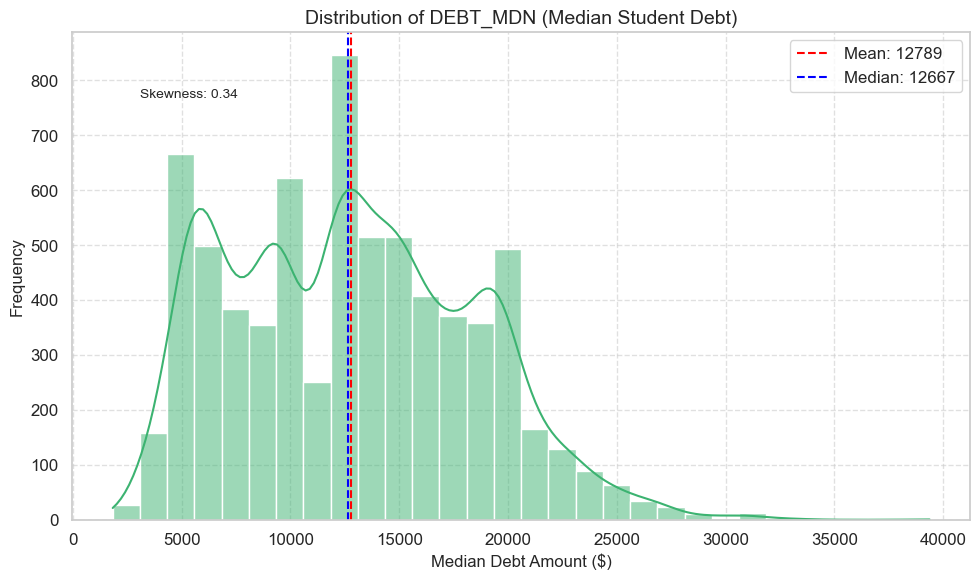

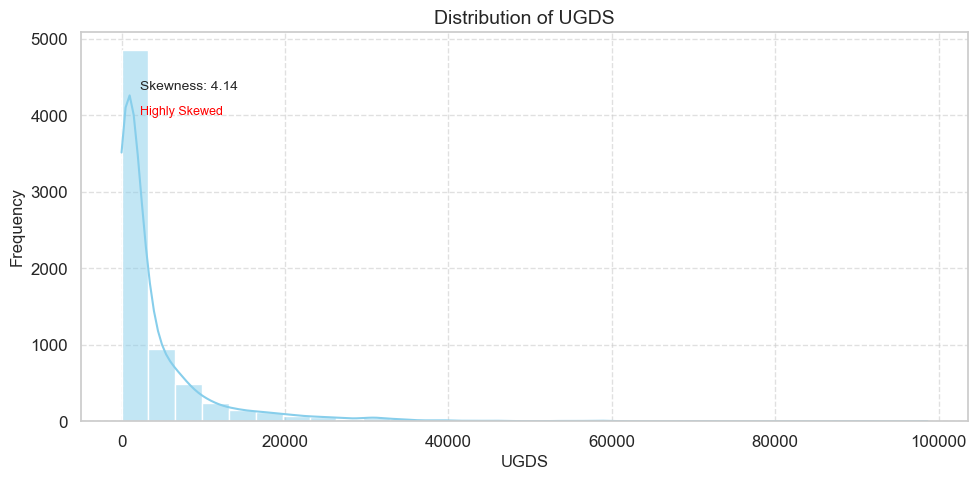

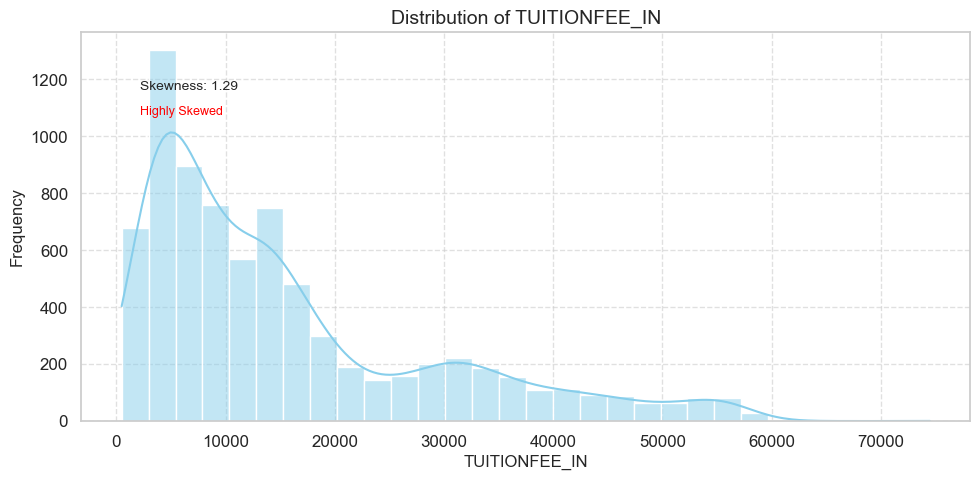

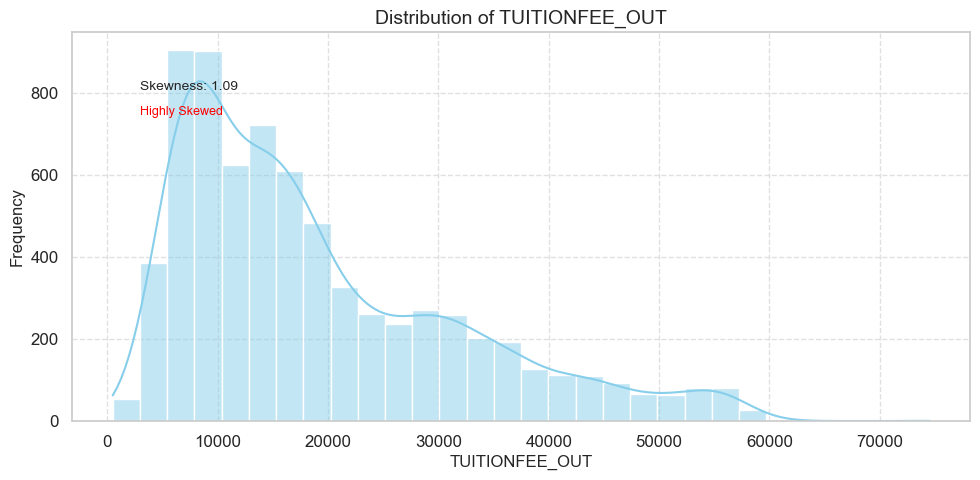

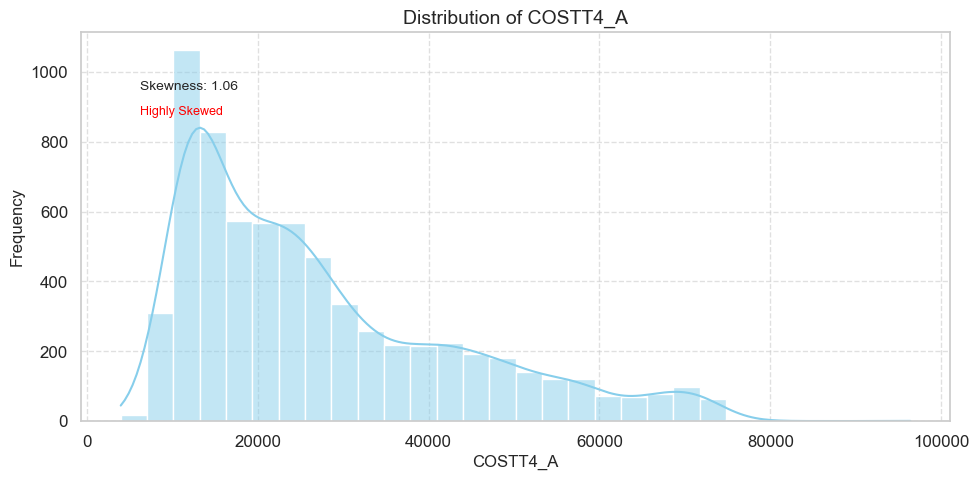

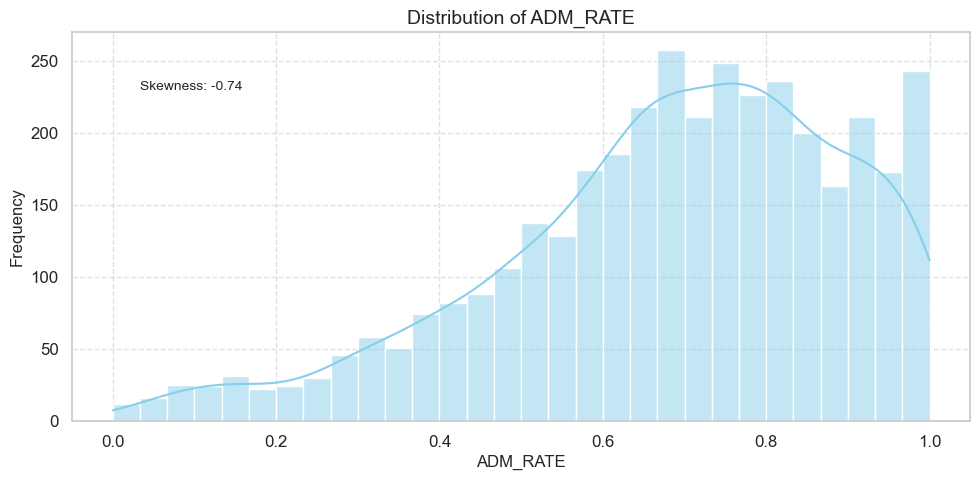

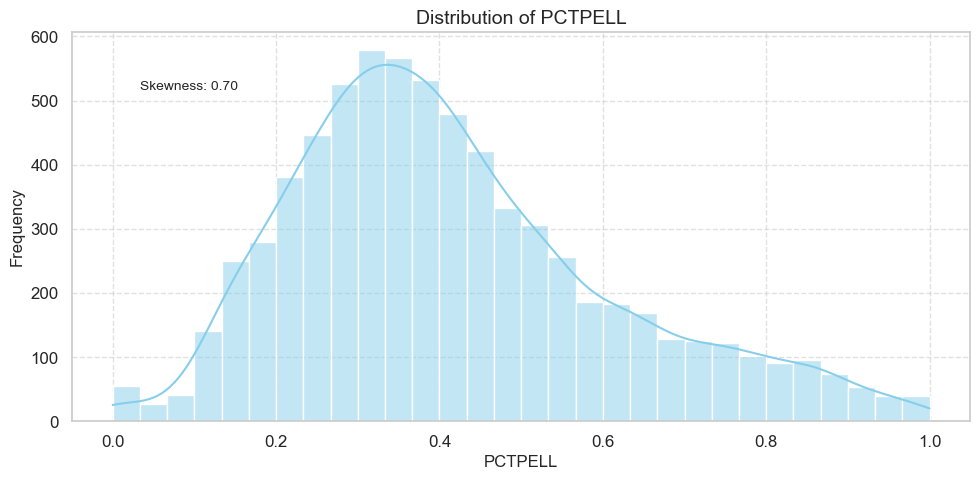

In [33]:

# Analyzing Missing Values
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_percent})
missing_summary_filtered = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary_sorted = missing_summary_filtered.sort_values(by='Missing %', ascending=True)

plt.figure(figsize=(12, 6))
missing_summary_sorted['Missing %'].plot(kind='barh', color='coral')
plt.xlabel('Percentage of Missing Values')
plt.title('Missing Data by Feature')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Missing Values Summary Table:\n")
print(missing_summary_filtered.sort_values(by='Missing %', ascending=False))

#Descriptive Statistics & Skewness
numeric_df = df.select_dtypes(include=['number'])
print("="*60)
print("Descriptive Statistics of Numerical Features")
print("="*60)
print(numeric_df.describe().T)

print("\n" + "="*60)
print("Skewness of Numerical Features")
print("="*60)
skewness_values = numeric_df.skew().sort_values(ascending=False)
print(skewness_values)

plt.figure(figsize=(12, 6))
skewness_values.plot(kind='bar', color='skyblue')
plt.axhline(1, color='red', linestyle='--', label='High Skew Threshold')
plt.axhline(-1, color='red', linestyle='--')
plt.title('Skewness of Numerical Features')
plt.ylabel('Skewness')
plt.xlabel('Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Target Variable Distribution Analysis
target_col = 'DEBT_MDN'
debt_data = df[target_col].dropna()
skewness_value = skew(debt_data)

plt.figure(figsize=(10, 6))
sns.histplot(debt_data, kde=True, bins=30, color='mediumseagreen')
plt.title(f'Distribution of {target_col} (Median Student Debt)', fontsize=14)
plt.xlabel('Median Debt Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(debt_data.mean(), color='red', linestyle='--', label=f"Mean: {debt_data.mean():.0f}")
plt.axvline(debt_data.median(), color='blue', linestyle='--', label=f"Median: {debt_data.median():.0f}")
plt.figtext(0.15, 0.82, f"Skewness: {skewness_value:.2f}", fontsize=10)
if abs(skewness_value) > 1:
    plt.figtext(0.15, 0.77, "Note: Highly skewed distribution", fontsize=9, color='crimson')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Numerical Feature Distributions and skewness
numerical_features = [
    'UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT',
    'COSTT4_A', 'ADM_RATE', 'PCTPELL'
]

for feature in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[feature].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    skew_value = skew(df[feature].dropna())
    plt.figtext(0.15, 0.8, f'Skewness: {skew_value:.2f}', fontsize=10)
    if abs(skew_value) > 1:
        plt.figtext(0.15, 0.75, 'Highly Skewed', fontsize=9, color='red')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


CORRELATION HEATMAP

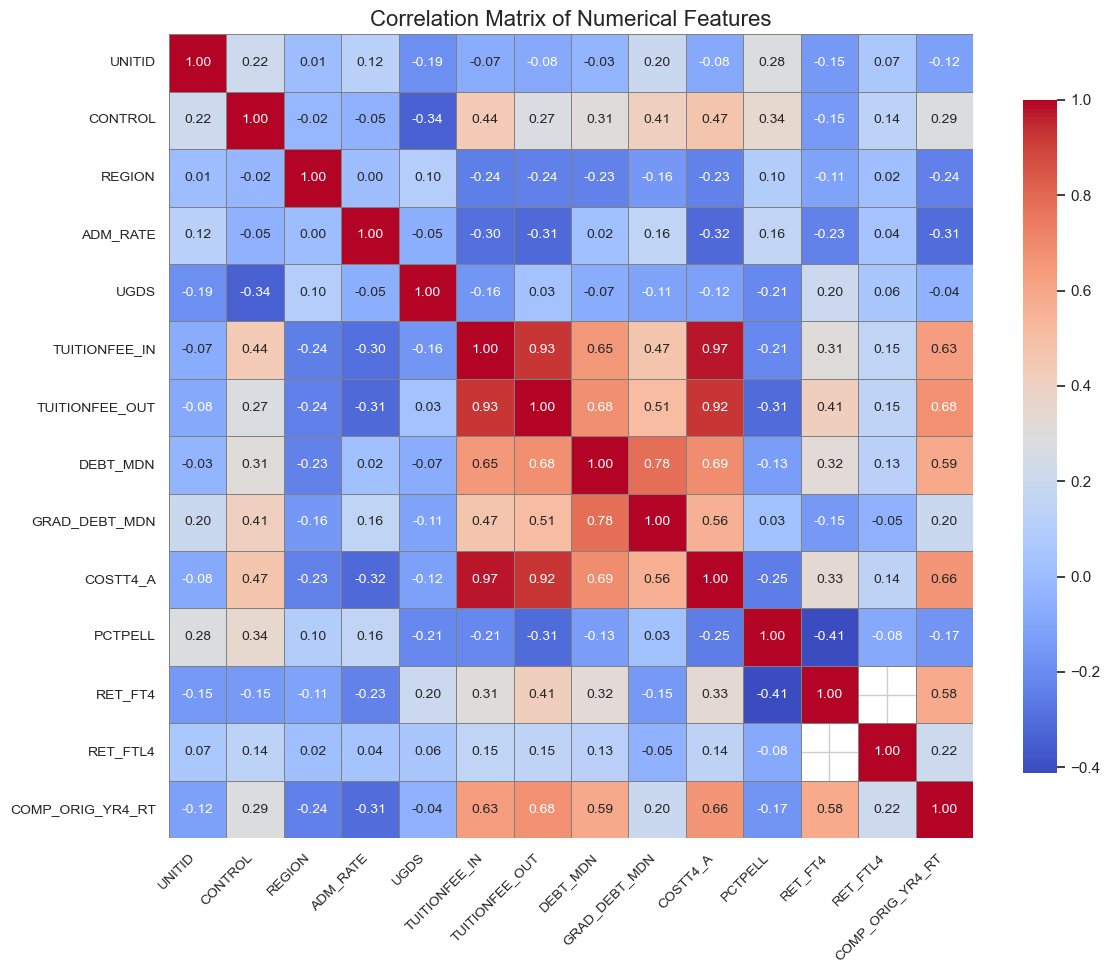

In [77]:
# Selecting numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Computing correlation matrix
corr_matrix = numeric_df.corr()

# Focusing on correlations with the target variable
target_corr = corr_matrix[['DEBT_MDN']].sort_values(by='DEBT_MDN', ascending=False)

# Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=0.5, linecolor='gray',
            annot_kws={"size": 10}, cbar_kws={'shrink': 0.8})

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


TARGET VARIABLE COMPARISON

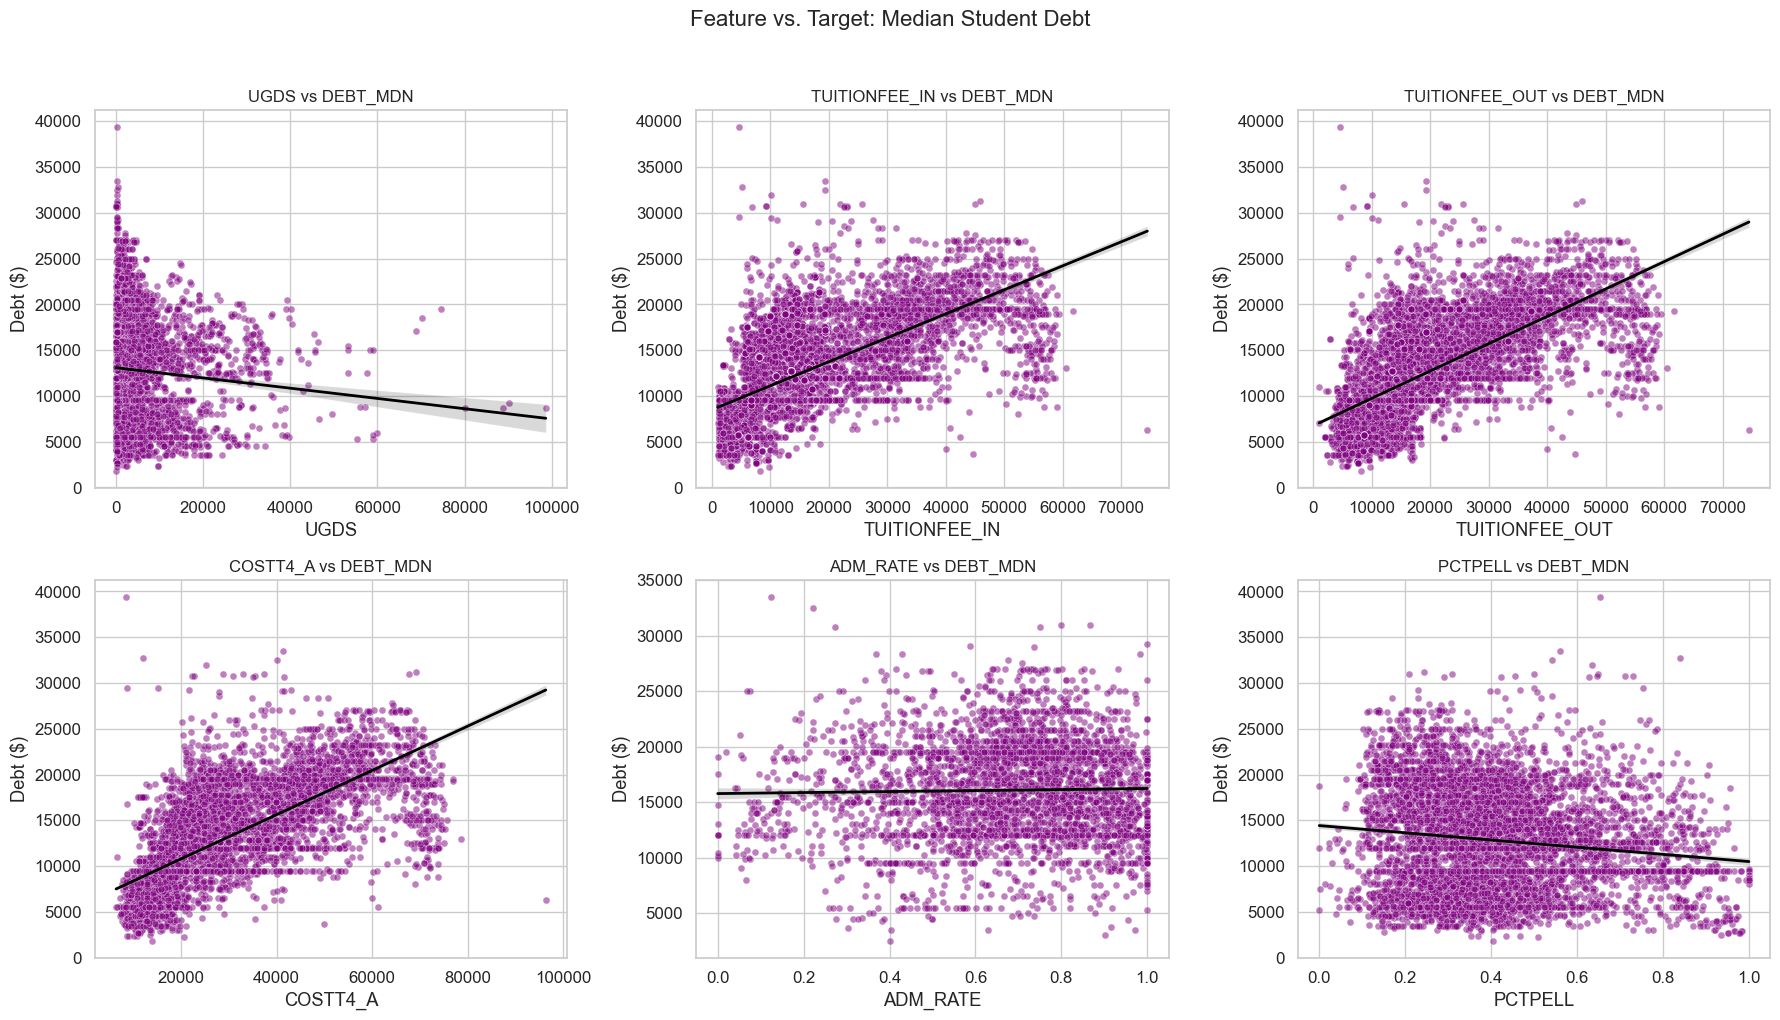

In [40]:
#Plot theme
sns.set(style='whitegrid', font_scale=1.1)

# Features and Target comparison
features = ['UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'COSTT4_A', 'ADM_RATE', 'PCTPELL']
target = 'DEBT_MDN'

# subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows x 3 columns
axes = axes.flatten()

# Loop and plot each subplot
for i, feature in enumerate(features):
    df_plot = df[[feature, target]].dropna()

    sns.scatterplot(ax=axes[i], data=df_plot, x=feature, y=target, color='purple', alpha=0.5, s=25)
    sns.regplot(ax=axes[i], data=df_plot, x=feature, y=target, scatter=False, color='black', line_kws={'linewidth': 2})
    
    axes[i].set_title(f'{feature} vs {target}', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Debt ($)')
plt.suptitle('Feature vs. Target: Median Student Debt', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 4. MODEL SELECTION AND TRAINING

In [48]:
# features and target
features = ['UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'COSTT4_A', 'ADM_RATE', 'PCTPELL', 'CONTROL']
target = 'DEBT_MDN'

# Drop rows with missing values
df_model = df[features + [target]].apply(pd.to_numeric, errors='coerce')
df_model = df_model.dropna()

# Split data
X = df_model[features]
y = df_model[target]

# Train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 2385
Testing samples: 1023


### 5. MODEL PERFORMANCE AND EVALUATION

In [54]:
# Cleaning and transforming the dataset 
df_model = df[features + [target]].apply(pd.to_numeric, errors='coerce').dropna()

# Log transformation
df_log = df_model.copy()
for col in ['UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'COSTT4_A']:
    df_log[col] = np.log1p(df_log[col])
df_log['DEBT_MDN_LOG'] = np.log1p(df_log['DEBT_MDN'])

# Removing outliers using Z-score
z_scores = np.abs(zscore(df_log[features + ['DEBT_MDN_LOG']]))
df_no_outliers = df_log[(z_scores < 3).all(axis=1)]

# Feature scaling
X = df_no_outliers[features]
y = df_no_outliers['DEBT_MDN_LOG']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Model 1 : Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb_log = gb_model.predict(X_test)
y_pred_gb = np.expm1(y_pred_gb_log)
y_test_orig = np.expm1(y_test)

r2_gb = r2_score(y_test_orig, y_pred_gb)
mse_gb = mean_squared_error(y_test_orig, y_pred_gb)

print("Gradient Boosting Performance:")
print("R-squared (R²):", round(r2_gb, 4))
print("Mean Squared Error (MSE):", round(mse_gb, 2))


# Model 2 : Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

r2_rf = r2_score(y_test_orig, y_pred_rf)
mse_rf = mean_squared_error(y_test_orig, y_pred_rf)

print("\nRandom Forest Performance:")
print("R-squared (R²):", round(r2_rf, 4))
print("Mean Squared Error (MSE):", round(mse_rf, 2))


Gradient Boosting Performance:
R-squared (R²): 0.4686
Mean Squared Error (MSE): 9408577.78

Random Forest Performance:
R-squared (R²): 0.5098
Mean Squared Error (MSE): 8678297.87


5.1 RESIDUAL PLOTS 

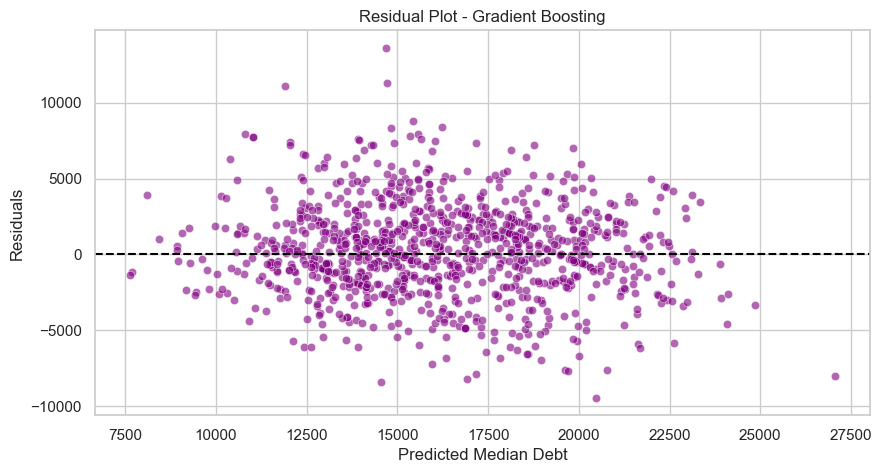

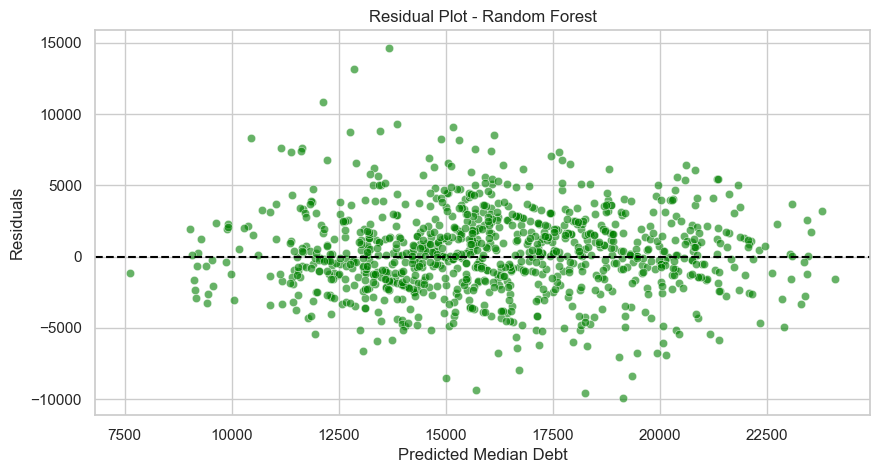

In [68]:
# Set plot style
sns.set(style='whitegrid')

# Residuals plot for Gradient Boosting
residuals_gb = y_test_orig - y_pred_gb

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_gb, y=residuals_gb, alpha=0.6, color='purple')
plt.axhline(0, linestyle='--', color='black')
plt.title("Residual Plot - Gradient Boosting")
plt.xlabel("Predicted Median Debt")
plt.ylabel("Residuals")
plt.show()


# Residual plot for Random Forest
residuals_rf = y_test_orig - y_pred_rf

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_rf, y=residuals_rf, alpha=0.6, color='green')
plt.axhline(0, linestyle='--', color='black')
plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Median Debt")
plt.ylabel("Residuals")
plt.show()


### 6. FEATURE IMPORTANCE

C:\Users\ACER\AppData\Local\Temp\ipykernel_27384\3358157111.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


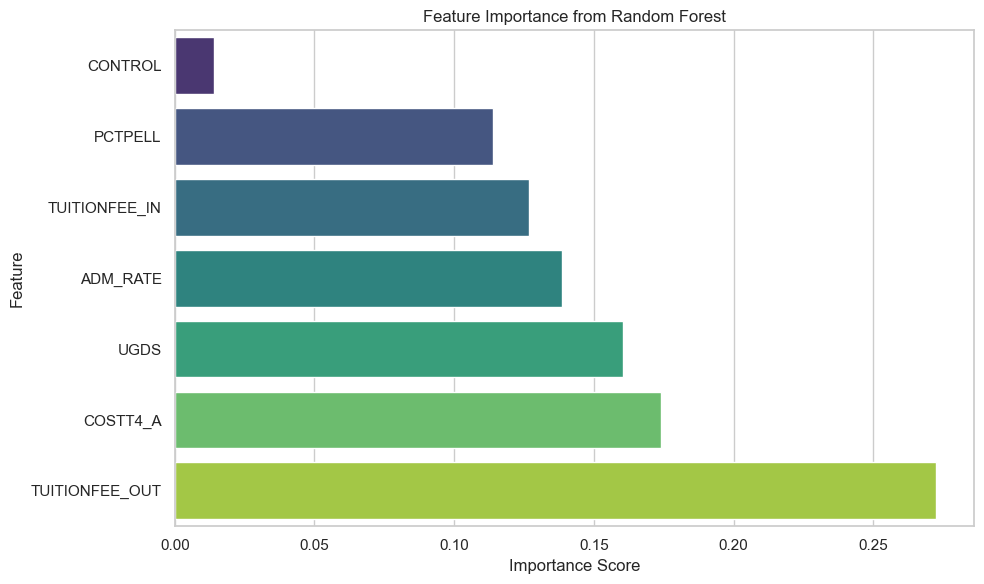

In [60]:
# Make sure you're using the trained RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# Example: Assuming you already trained it
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Then use the Random Forest model to get feature importances
importance_scores = rf_model.feature_importances_

# Create DataFrame for display
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 7. MODEL SUMMARY

In [95]:
comparison_df = pd.DataFrame({
    'Model': [ 
        'Random Forest', 
        'Gradient Boosting'
    ],
    'R-squared (R²)': [0.5126, 0.4612],
    'Mean Squared Error (MSE)': [9503123.38, 10755649.21]
})
print("Model Comparison Summary - Dataset 2:\n")
print(comparison_df.to_string(index=False))


Model Comparison Summary - Dataset 2:

            Model  R-squared (R²)  Mean Squared Error (MSE)
    Random Forest          0.5126                9503123.38
Gradient Boosting          0.4612               10755649.21
